# CS60010 — Deep Learning | Spring 2026
## Assignment 2: Open Architecture Design Challenge on ARC-AGI
---
**Team Members:**
| Name | Roll Number |
|---|---|
| Pallab Biswas | 23EE10092 |
| Arghyadeep Ghosh | 25CS91R03 |
| Piyush Sarangi| 23EE10082|
| Ajitesh Jamulkar |22CS10004  |
| Ansh Sahu | 22CS30010|

**Architecture:** Tiny Recursive Model (TRM) with 3-D RoPE  
**Ablation Baseline:** Hierarchical Reasoning Model (HRM)  
**Parameter Budget:** ≤ 50 Million (trained from scratch)  
**Dataset:** ARC-AGI-1 — 400 training tasks, 400 evaluation tasks


# FILES UPLOAD

In [ ]:
from google.colab import files  
import os
import shutil
import zipfile

In [ ]:
# Ensure the checkpoints directory exists
os.makedirs('checkpoints', exist_ok=True)

# Upload the file from your computer
print("Please select your 'checkpoint_epoch_016.pt' file:")
uploaded = files.upload()

# Move the file to the 'checkpoints' folder
for filename in uploaded.keys():
    dst_path = os.path.join('checkpoints', filename)
    shutil.move(filename, dst_path)
    print(f"Successfully moved {filename} to {dst_path}")

# Verify the file is there
print("\nCurrent files in checkpoints/ folder:")
print(os.listdir('checkpoints'))

In [ ]:
files.upload()

In [ ]:
with zipfile.ZipFile("data.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [ ]:
print(os.listdir("/content/"))
print(os.listdir("/content/data"))
print(os.listdir("/content/data/training")[:5])

['.config', 'checkpoints', 'data', 'data.zip', 'sample_data']
['evaluation', 'training']
['91714a58.json', 'c9e6f938.json', 'c909285e.json', '0a938d79.json', '4347f46a.json']


# CODE

In [ ]:
import os, json, math, copy, random, itertools
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.amp import GradScaler, autocast
from einops import rearrange

# Reproducibility 
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Device 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu") # for local testing we are using our MAC's GPU - MPS
print(f"[Config] Using device: {DEVICE}")

# ARC constants  
NUM_COLORS   = 10      # colour tokens 0–9
MAX_GRID_DIM = 30
MAX_SEQ_LEN  = 2048
PAD_TOKEN    = 10      # padding
SEP_TOKEN    = 11      # separator between input/output grids
NUM_TOKENS   = 12      # vocab size

# Paths 
DATA_ROOT = Path("/content/data")
TRAIN_DIR = DATA_ROOT / "training"
EVAL_DIR  = DATA_ROOT / "evaluation"
CKPT_DIR  = Path("checkpoints"); CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ── Dihedral-8 geometric augmentations ───────────────────
def rotate90(g): return np.rot90(g, k=1).copy()
def flip_h(g):   return np.fliplr(g).copy()
DIHEDRAL_OPS = [
    lambda g: g,
    lambda g: rotate90(g),
    lambda g: rotate90(rotate90(g)),
    lambda g: rotate90(rotate90(rotate90(g))),
    lambda g: flip_h(g),
    lambda g: flip_h(rotate90(g)),
    lambda g: flip_h(rotate90(rotate90(g))),
    lambda g: flip_h(rotate90(rotate90(rotate90(g)))),
]

MAX_TGT = 30 * 30  # 900 max tokens


[Config] Using device: cuda


In [ ]:
def load_arc_tasks(task_dir: Path) -> List[Dict]:
    """Load all ARC JSON task files from a directory."""
    tasks = []
    for fp in sorted(task_dir.glob("*.json")):
        with open(fp) as f:
            raw = json.load(f)
        tasks.append({"task_id": fp.stem, "train": raw["train"], "test": raw["test"]})
    return tasks


def augment_geometric(task, op_idx):
    op = DIHEDRAL_OPS[op_idx]
    def ap(pair, with_out=True):
        inp = op(np.array(pair["input"], dtype=np.int8))
        if with_out and "output" in pair:
            return {"input": inp.tolist(), "output": op(np.array(pair["output"], dtype=np.int8)).tolist()}
        return {"input": inp.tolist()}
    return {"task_id": task["task_id"]+f"_d{op_idx}",
            "train": [ap(p) for p in task["train"]],
            "test":  [ap(p, False) for p in task["test"]]}

def is_colour_identity(task):
    """True if output introduces colours absent from input → skip colour perm."""
    for p in task["train"]:
        if set(np.array(p["output"]).flatten()) - set(np.array(p["input"]).flatten()):
            return True
    return False

def augment_colour(task, perm):
    lut = np.array(perm, dtype=np.int8)
    def ap(g): return lut[np.array(g, dtype=np.int8)].tolist()
    def apair(p, with_out=True):
        d = {"input": ap(p["input"])}
        if with_out and "output" in p: d["output"] = ap(p["output"])
        return d
    return {"task_id": task["task_id"]+"_cp",
            "train": [apair(p) for p in task["train"]],
            "test":  [apair(p, False) for p in task["test"]]}

def build_augmented_dataset(raw_tasks, colour_aug=True):
    augmented = []
    for task in raw_tasks:
        for i in range(8):
            augmented.append(augment_geometric(task, i))
        if colour_aug and not is_colour_identity(task):
            perm = list(range(10)); random.shuffle(perm)
            augmented.append(augment_colour(task, perm))
    print(f"[Dataset] {len(raw_tasks)} tasks → {len(augmented)} augmented")
    return augmented


In [ ]:
# ── Grid serialisation ────────────────────────────────────
def grid_to_tokens(grid):
    return torch.tensor([c for row in grid for c in row], dtype=torch.long)

def tokens_to_grid(tokens, H, W):
    flat = tokens.cpu().numpy().tolist()[:H*W]
    return [[min(9, max(0, flat[r*W+c])) for c in range(W)] for r in range(H)]

def build_sequence(task, pair_idx_for_test=0):
    """Serialise task → (src_tokens, tgt_tokens, pair_indices, rc_ids, tgt_h, tgt_w)."""
    demo_pairs = task["train"]
    test_pair  = task["test"][pair_idx_for_test]
    src, pidx, rcids = [], [], []

    for p, pair in enumerate(demo_pairs):
        for r, row in enumerate(pair["input"]):
            for c, val in enumerate(row):
                src.append(val); pidx.append(p); rcids.append((r, c))
        src.append(SEP_TOKEN); pidx.append(p); rcids.append((0, 0))
        for r, row in enumerate(pair["output"]):
            for c, val in enumerate(row):
                src.append(val); pidx.append(p); rcids.append((r, c))
        src.append(SEP_TOKEN); pidx.append(p); rcids.append((0, 0))

    test_inp = test_pair["input"]
    tgt_grid = test_pair.get("output", None)
    tgt_h    = len(tgt_grid)    if tgt_grid else 0
    tgt_w    = len(tgt_grid[0]) if tgt_grid else 0
    n_demo   = len(demo_pairs)
    for r, row in enumerate(test_inp):
        for c, val in enumerate(row):
            src.append(val); pidx.append(n_demo); rcids.append((r, c))

    src = src[:MAX_SEQ_LEN]; pidx = pidx[:MAX_SEQ_LEN]; rcids = rcids[:MAX_SEQ_LEN]
    tgt = grid_to_tokens(tgt_grid) if tgt_grid else torch.zeros(1, dtype=torch.long)
    return (torch.tensor(src, dtype=torch.long), tgt,
            torch.tensor(pidx, dtype=torch.long), rcids, tgt_h, tgt_w)

In [ ]:
# ============================================================
# DATASET UTILITIES
# ============================================================
# This section provides utility classes and functions for preparing the ARC dataset
# for model training and evaluation. Includes a Dataset for leave-one-out-style
# cross-validation and a custom collate function for proper batching & padding.

class ARCDataset(Dataset):
    """
    PyTorch Dataset for the ARC challenge.
    Prepares samples by leaving one training pair out as a pseudo-test (target),
    using the rest as context demonstrations.
    - For each (task, training demo), creates a synthetic sample where 
      that demo is the held-out target to be predicted.
    """
    def __init__(self, tasks):
        self.samples = []
        for t in tasks:
            n = len(t["train"])
            if n < 2:
                continue   # Must have at least 1 context demo + 1 target
            for hold in range(n):
                self.samples.append((t, hold))  # Hold out each demo in turn

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        t, hold = self.samples[idx]
        ctx_task = {
            "task_id": t["task_id"],
            "train":   [p for i, p in enumerate(t["train"]) if i != hold],
            "test":    [t["train"][hold]],
        }
        # Tokenize serialized context + target and gather all metadata for batching
        src, tgt, pidx, rcids, th, tw = build_sequence(ctx_task, pair_idx_for_test=0)
        return {
            "src": src,
            "tgt": tgt,
            "pair_idx": pidx,
            "rc_ids": rcids,
            "tgt_h": th,
            "tgt_w": tw,
            "task_id": t["task_id"]
        }

def arc_collate_fn(batch):
    """
    Custom collate function for DataLoader.
    Pads all input/output sequences in the minibatch to the max length in batch,
    collects all relevant meta-info (row/col indices, target dimensions, etc).
    """
    ml = max(b["src"].shape[0] for b in batch)                    # max input seq len
    mt = max(max(1, b["tgt_h"] * b["tgt_w"]) for b in batch)      # max target seq len (1 if empty)
    sp, pp, ms, tgts, tgt_masks, rc = [], [], [], [], [], []      # batch containers

    for b in batch:
        L = b["src"].shape[0]
        pad = ml - L
        sp.append(F.pad(b["src"], (0, pad), value=PAD_TOKEN))         # pad input token ids
        pp.append(F.pad(b["pair_idx"], (0, pad), value=0))            # pad pair indices
        m = torch.zeros(ml, dtype=torch.bool); m[L:] = True; ms.append(m)  # pad mask

        # Pad row/col ids to sequence length (used for positional encodings)
        rc.append(b["rc_ids"] + [(0, 0)] * pad)

        T_out = b["tgt_h"] * b["tgt_w"]
        tgt_pad = F.pad(b["tgt"][:T_out], (0, mt - T_out), value=PAD_TOKEN) 
        tgts.append(tgt_pad)
        tmask = torch.zeros(mt, dtype=torch.bool); tmask[T_out:] = True
        tgt_masks.append(tmask)      

    return {
        "src": torch.stack(sp),
        "pair_idx": torch.stack(pp),
        "src_mask": torch.stack(ms),
        "tgt": torch.stack(tgts),
        "tgt_mask": torch.stack(tgt_masks),
        "rc_ids": rc,                    # (batch, seq_len, 2) - (row, col) for positions
        "tgt_h": [b["tgt_h"] for b in batch],
        "tgt_w": [b["tgt_w"] for b in batch],
        "task_id": [b["task_id"] for b in batch]
    }
        
print(" Dataset utilities loaded (leave-one-out training fix applied).")


 Dataset utilities loaded (leave-one-out training fix applied).


In [13]:
# ============================================================
# 3-D Rotary Positional Embeddings (RoPE)
# ============================================================
# Design rationale: ARC rules are fundamentally spatial AND relational.
# 3-D RoPE encodes (row, col, pair_index) without learned parameters,
# critical for generalising with only 400 training tasks.

class RoPE3D(nn.Module):
    """
    Three-dimensional RoPE encoding (row, col, pair_index) for each token.
    The head dimension is split equally across the three axes.
    """
    def __init__(self, head_dim: int, max_pos: int = 64, max_pairs: int = 8):
        super().__init__()
        assert head_dim % 6 == 0, "head_dim must be divisible by 6"
        self.dim_each = head_dim // 3
        for name, mx in [("row", max_pos), ("col", max_pos), ("pair", max_pairs)]:
            d = self.dim_each // 2
            inv = 1.0 / (10000 ** (torch.arange(0, d, dtype=torch.float) / d))
            self.register_buffer(f"inv_freq_{name}", inv)

    def _cs(self, pos, inv):
        f = torch.outer(pos.float(), inv)
        e = torch.cat([f, f], dim=-1)
        return e.cos(), e.sin()

    def rotate_half(self, x):
        x1, x2 = x.chunk(2, dim=-1)
        return torch.cat([-x2, x1], dim=-1)

    def forward(self, q, k, rows, cols, pairs):
        T = q.shape[2]
        cos_r, sin_r = self._cs(rows[:T], self.inv_freq_row)
        cos_c, sin_c = self._cs(cols[:T], self.inv_freq_col)
        cos_p, sin_p = self._cs(pairs[:T], self.inv_freq_pair)
        cos = torch.cat([cos_r, cos_c, cos_p], -1).to(q.device)[None, None]
        sin = torch.cat([sin_r, sin_c, sin_p], -1).to(q.device)[None, None]
        return q*cos + self.rotate_half(q)*sin, k*cos + self.rotate_half(k)*sin

print(" RoPE3D loaded.")


 RoPE3D loaded.


In [ ]:
# ============================================================
# Transformer building blocks
# ============================================================
# Transformer architecture building blocks:
# Stacked blocks with multi-head self-attention (using 3D RoPE) and feed-forward networks,
# combined via pre-layer normalization, enable deep relational reasoning. TinyTransformer wraps these layers for the main model.

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.hd = d_model // n_heads
        self.qkv  = nn.Linear(d_model, 3*d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model, bias=False)
        self.drop = nn.Dropout(dropout)
        self.rope = RoPE3D(self.hd)

    def forward(self, x, rows, cols, pairs, key_padding_mask=None):
        B, T, D = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.n_heads, self.hd).permute(2,0,3,1,4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        q, k = self.rope(q, k, rows, cols, pairs)
        attn = (q @ k.transpose(-2,-1)) / math.sqrt(self.hd)
        if key_padding_mask is not None:
            attn = attn.masked_fill(key_padding_mask[:,None,None,:], float('-inf'))
        attn = self.drop(F.softmax(attn, dim=-1))
        out  = (attn @ v).transpose(1,2).reshape(B, T, D)
        return self.proj(out)

class FFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout))
    def forward(self, x): return self.net(x)

class TransformerBlock(nn.Module):
    """Pre-LayerNorm transformer block (more training-stable than post-LN)."""
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn  = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn   = FFN(d_model, d_ff, dropout)
    def forward(self, x, rows, cols, pairs, kpm=None):
        x = x + self.attn(self.norm1(x), rows, cols, pairs, kpm)
        x = x + self.ffn(self.norm2(x))
        return x

class TinyTransformer(nn.Module):
    """Shared 2-layer bidirectional encoder used inside TRM recursion."""
    def __init__(self, d_model, n_heads, d_ff, n_layers=2, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [TransformerBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
    def forward(self, x, rows, cols, pairs, kpm=None):
        for l in self.layers: x = l(x, rows, cols, pairs, kpm)
        return x
   

print("Transformer blocks loaded.")


Transformer blocks loaded.


In [16]:
# ============================================================
#  Tiny Recursive Model (TRM) — PRIMARY ARCHITECTURE
# ============================================================
#
# Mathematical formulation:
#   At each cycle t:
#     Inner (n_inner steps):  z^i = f_inner( cat(x_ctx, y, z^{i-1}) )
#     Answer update:          y   = f_update( cat(y, z^{n_inner}) )
#   Prediction:               logits = head(y)
#   Deep supervision:         Loss = Σ_t  γ^{T-t} · CE(logits_t, y_gold)
#
# Separating y (answer) and z (reasoning) prevents z from wasting
# capacity tracking answer format → richer intermediate representations.

class TRM(nn.Module):
    def __init__(self, d_model=96, n_heads=4, d_ff=256, n_layers=2,
                 n_inner=6, T_cycles=3, dropout=0.1, max_pairs=5):
        super().__init__()
        self.d_model  = d_model
        self.n_inner  = n_inner
        self.T_cycles = T_cycles

        self.token_emb = nn.Embedding(NUM_TOKENS, d_model, padding_idx=PAD_TOKEN)
        self.pair_emb  = nn.Embedding(max_pairs+1, d_model)

        # Inner recursion: [x_ctx ; y ; z] → z'
        self.proj_in  = nn.Linear(3*d_model, d_model)
        self.f_inner  = TinyTransformer(d_model, n_heads, d_ff, n_layers, dropout)

        # Answer update: [y ; z] → y'
        self.proj_ya  = nn.Linear(2*d_model, d_model)
        self.f_update = TinyTransformer(d_model, n_heads, d_ff, n_layers, dropout)

        self.head      = nn.Linear(d_model, NUM_COLORS)
        self.halt_head = nn.Linear(d_model, 1)   # ACT halting scalar
        self.drop      = nn.Dropout(dropout)

    def embed(self, src, pair_idx):
        return self.drop(self.token_emb(src) + self.pair_emb(pair_idx))

    def forward(self, src, pair_idx, tgt_len,
                rows_ctx, cols_ctx, pairs_ctx,
                rows_tgt, cols_tgt, pairs_tgt, src_mask=None):
        B = src.shape[0]
        x = self.embed(src, pair_idx)                     # (B, T, D)

        y = torch.zeros(B, tgt_len, self.d_model, device=src.device)
        z = torch.zeros(B, tgt_len, self.d_model, device=src.device)

        all_logits = []
        for _ in range(self.T_cycles):
            # Inner recursion: refine z given context, y, z
            for _ in range(self.n_inner):
                ctx = x.mean(1, keepdim=True).expand(B, tgt_len, -1)
                z   = self.f_inner(
                        F.gelu(self.proj_in(torch.cat([ctx, y, z], -1))),
                        rows_tgt, cols_tgt, pairs_tgt)

            # Answer update: refine y given y and z
            y = self.f_update(
                    F.gelu(self.proj_ya(torch.cat([y, z], -1))),
                    rows_tgt, cols_tgt, pairs_tgt)

            all_logits.append(self.head(y))

        return all_logits[-1], all_logits

print("TRM loaded.")


TRM loaded.


In [ ]:
# ============================================================
# HRM (Hierarchical Reasoning Model) — ABLATION BASELINE
# ============================================================
# Key differences from TRM:
#   • Two networks: f_L (low-level) and f_H (high-level, 4-layer)
#   • Two latent states: z_L (spatial) and z_H (rule-level)
#   • 1-step gradient approximation (stop-gradient on z_L when training f_H)
#     rather than full backpropagation through the entire recursion.
# This ablation isolates the effect of full backpropagation vs. IFT approximation.

class HRM(nn.Module):
    def __init__(self, d_model=96, n_heads=4, d_ff=256,
                 n_layers_L=2, n_layers_H=4, n_inner=4, T_cycles=3, dropout=0.1):
        super().__init__()
        self.d_model  = d_model
        self.n_inner  = n_inner
        self.T_cycles = T_cycles

        self.token_emb = nn.Embedding(NUM_TOKENS, d_model, padding_idx=PAD_TOKEN)
        self.pair_emb  = nn.Embedding(8, d_model)

        self.proj_L = nn.Linear(3*d_model, d_model)
        self.f_L    = TinyTransformer(d_model, n_heads, d_ff, n_layers_L, dropout)

        self.proj_H = nn.Linear(2*d_model, d_model)
        self.f_H    = TinyTransformer(d_model, n_heads, d_ff, n_layers_H, dropout)

        self.head = nn.Linear(d_model, NUM_COLORS)
        self.drop = nn.Dropout(dropout)

    def embed(self, src, pair_idx):
        return self.drop(self.token_emb(src) + self.pair_emb(pair_idx))

    def forward(self, src, pair_idx, tgt_len,
                rows_ctx, cols_ctx, pairs_ctx,
                rows_tgt, cols_tgt, pairs_tgt, src_mask=None):
        B  = src.shape[0]
        x  = self.embed(src, pair_idx)
        y  = torch.zeros(B, tgt_len, self.d_model, device=src.device)
        zL = torch.zeros(B, tgt_len, self.d_model, device=src.device)
        zH = torch.zeros(B, tgt_len, self.d_model, device=src.device)
        all_logits = []

        for _ in range(self.T_cycles):
            ctx = x.mean(1, keepdim=True).expand(B, tgt_len, -1)
            zL_in = F.gelu(self.proj_L(torch.cat([ctx, y, zL], -1)))
            for _ in range(self.n_inner):
                zL = self.f_L(zL_in, rows_tgt, cols_tgt, pairs_tgt)
                zL_in = zL
            # Stop-gradient: 1-step approximation (ablation condition)
            zH = self.f_H(F.gelu(self.proj_H(torch.cat([zH, zL.detach()], -1))),
                          rows_tgt, cols_tgt, pairs_tgt)
            y  = zH
            all_logits.append(self.head(y))

        return all_logits[-1], all_logits

print("HRM ablation baseline loaded.")


HRM ablation baseline loaded.


In [19]:
# ============================================================
#  Parameter counter, positional helpers, loss, EMA, scheduler
# ============================================================

def count_parameters(model, label="Model"):
    """Count & print trainable parameters. Asserts ≤ 50M budget."""
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    for name, mod in model.named_children():
        n = sum(p.numel() for p in mod.parameters() if p.requires_grad)
        print(f"  {name:<22s}  {n:>12,d}")
    print(f"{'─'*55}")
    print(f"  {'TOTAL':<22s}  {total:>12,d}")
    assert total <= 50_000_000, f"BUDGET EXCEEDED: {total:,} > 50,000,000"
    print(f"  ✓ Within 50M budget  ({total/1e6:.3f}M / 50.000M)")
    print(f"{'='*55}\n")
    return total

In [20]:
# Positional index helpers 
def build_pos_tensors(rc_ids):
    rows = torch.tensor([r for r, _ in rc_ids], dtype=torch.long)
    cols = torch.tensor([c for _, c in rc_ids], dtype=torch.long)
    return rows, cols

In [21]:
def tgt_pos_tensors(H, W, pair_idx=4):
    rows, cols = [], []
    for r in range(H):
        for c in range(W):
            rows.append(r); cols.append(c)
    T = len(rows)
    return (torch.tensor(rows, dtype=torch.long),
            torch.tensor(cols, dtype=torch.long),
            torch.full((T,), pair_idx, dtype=torch.long))

In [22]:
# Deep-supervision loss
def deep_supervision_loss(all_logits, tgt, gamma=0.5):
    """
    Loss = Σ_t  γ^{T-t-1} · CE(logits_t, tgt)
    Earlier cycles discounted; model primarily optimised on final answer.
    """
    T  = len(all_logits)
    ws = [gamma**(T-1-t) for t in range(T)]
    loss = torch.tensor(0.0, device=all_logits[0].device)
    for lg, w in zip(all_logits, ws):
        B, L, C = lg.shape
        loss += w * F.cross_entropy(lg.reshape(B*L, C), tgt.reshape(B*L),
                                    ignore_index=PAD_TOKEN)
    return loss / sum(ws)

In [23]:
# EMA 
class EMA:
    """Exponential Moving Average of model weights for stable evaluation."""
    def __init__(self, model, decay=0.999):
        self.decay  = decay
        self.shadow = {n: p.data.clone().float()
                       for n, p in model.named_parameters() if p.requires_grad}

    @torch.no_grad()
    def update(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad and n in self.shadow:
                self.shadow[n] = self.decay*self.shadow[n] + (1-self.decay)*p.data.float()

    def apply(self, model):
        for n, p in model.named_parameters():
            if n in self.shadow: p.data.copy_(self.shadow[n].to(p.device))

    def restore(self, model, state):
        model.load_state_dict(state)


In [24]:
# WSD scheduler 
def build_wsd_scheduler(optimizer, total_steps, warmup_frac=0.05, decay_frac=0.20):
    """Warmup-Stable-Decay LR schedule.

    total_steps must equal the total number of optimizer (not scheduler) steps:
        total_steps = NUM_EPOCHS * (len(dataloader) // accum_steps)
    """
    we = int(total_steps * warmup_frac)
    ds = int(total_steps * (1 - decay_frac))
    def f(s):
        if s < we:  return s / max(1, we)
        if s < ds:  return 1.0
        return max(0.0, 1.0 - (s - ds) / max(1, total_steps - ds))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, f)

print(" Utilities loaded.")

 Utilities loaded.


In [ ]:
# ============================================================
# Training loop (one epoch)
# ============================================================
# Walks the training loader with mixed precision on CUDA.
# Gradients accumulate for `accum_steps` loader steps before one optimizer update.
# Loss is averaged over valid examples only; the LR scheduler steps with the optimizer.

def train_one_epoch(model, loader, optimizer, scheduler, ema, scaler,
                    device, accum_steps=4):
    """One epoch in train mode: per-example ARC targets, AMP, accumulation, EMA, optional WSD."""
    model.train()
    running_loss = 0.0   # Unscaled loss sum (we divide by count at the end)
    running_n    = 0     # Number of valid training pairs counted toward that sum

    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        src      = batch["src"].to(device)
        pair_idx = batch["pair_idx"].to(device)
        src_mask = batch["src_mask"].to(device)

        B = src.shape[0]
        bloss = torch.tensor(0.0, device=device)
        valid = 0

        # ARC grid sizes differ per row — accumulate loss across examples in this batch
        for i in range(B):
            th, tw = batch["tgt_h"][i], batch["tgt_w"][i]
            if th == 0:
                continue

            tgt_i = batch["tgt"][i].to(device)
            T_out = th * tw

            rcids = batch["rc_ids"][i]
            rc, cc = build_pos_tensors(rcids)
            rt, ct, pt = tgt_pos_tensors(th, tw, 4)

            # Prefer explicit device string (avoids deprecated dtype-only autocast)
            with autocast('cuda', dtype=torch.float16):
                _, all_logits = model(
                    src[i:i+1],
                    pair_idx[i:i+1],
                    T_out,
                    rc.to(device),
                    cc.to(device),
                    pair_idx[i],   # pair ids along the source sequence (length = seq_len)
                    rt.to(device),
                    ct.to(device),
                    pt.to(device),
                    src_mask[i:i+1]
                )
                loss = deep_supervision_loss(
                    all_logits,
                    tgt_i[:T_out].unsqueeze(0)
                )

            bloss += loss
            valid += 1

        if valid == 0:
            continue

        # Bookkeeping uses the real loss sum (before we scale down for accumulation)
        running_loss += bloss.item()
        running_n    += valid

        # Normalize so backward() sees the effective loss per accumulation step
        bloss = bloss / (valid * accum_steps)
        scaler.scale(bloss).backward()

        # Every accum_steps micro-batches: clipped unscaled step, EMA tick, LR tick
        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            ema.update(model)
            if scheduler is not None:
                scheduler.step()   # keeps WSD aligned with optimizer step count

    # Mean loss across all valid (batch, example) pairs in this epoch
    return running_loss / max(1, running_n)

print("Training loop loaded.")


Training loop loaded.


In [ ]:
# ============================================================
#  Inference, exact-match evaluation, Test-Time Training
# ============================================================
# Runs the frozen model on held-out test pairs (greedy and optional sampling).
# Scores a task list with strict grid equality — any candidate grid can count as a solve.
# TTT optionally adapts a *copy* of the weights on demo pairs before evaluation.

@torch.no_grad()
def predict_task(model, task, device, pair_idx_for_test=0, attempts=2):
    """One test pair → up to `attempts` output grids (e.g. greedy argmax + light sampling)."""
    model.eval()
    src, tgt, pidx, rcids, th, tw = build_sequence(task, pair_idx_for_test)
    # No training label yet — infer output size from the raw test input grid
    if th == 0:
        ti = task["test"][pair_idx_for_test]["input"]
        th, tw = len(ti), len(ti[0])

    src_d  = src.unsqueeze(0).to(device)
    pidx_d = pidx.unsqueeze(0).to(device)
    T_out  = th * tw
    rc, cc = build_pos_tensors(rcids)
    rt, ct, pt = tgt_pos_tensors(th, tw, 4)

    preds = []
    # temp=0 → deterministic decode; temp>0 → stochastic re-roll for diversity
    for temp in [0.0, 0.5][:attempts]:
        with autocast('cuda', dtype=torch.float16):
            fl, _ = model(src_d, pidx_d, T_out,
                          rc.to(device), cc.to(device), pidx_d.squeeze(0),
                          rt.to(device), ct.to(device), pt.to(device))
        lg = fl[0].float()
        if temp == 0.0:
            toks = lg.argmax(-1)
        else:
            toks = torch.multinomial(F.softmax(lg / temp, -1), 1).squeeze(-1)
        preds.append(tokens_to_grid(toks, th, tw))
    return preds

def evaluate_exact_match(model, tasks, device, max_tasks=None):
    """Fraction of tasks where every test case with a label matches at least one prediction."""
    solved = 0
    n = len(tasks) if max_tasks is None else min(len(tasks), max_tasks)
    for task in tasks[:n]:
        ok = True
        for pi, tp in enumerate(task["test"]):
            # Skip incomplete eval rows; otherwise require a hit among predict_task outputs
            if "output" not in tp: ok = False; break
            if not any(p == tp["output"] for p in predict_task(model, task, device, pi)):
                ok = False; break
        if ok: solved += 1
    acc = solved / n
    print(f"  Solved: {solved}/{n}  ({acc*100:.2f}%)")
    return acc

def test_time_train(model, task, device, n_steps=50, lr=1e-4):
    """
    Short inner-loop fine-tune on a deep-copied model: each demo example is the
    pseudo-test while the remaining demos supply context (ARC-legal TTT setup).
    """
    adapted = copy.deepcopy(model); adapted.train()
    opt = AdamW(adapted.parameters(), lr=lr)
    for _ in range(n_steps):
        for i, pair in enumerate(task["train"]):
            # Leave-one-demo-out: current pair is "test", others are training context
            ctx_task = {"task_id": task["task_id"]+"_ttt",
                        "train": [p for j, p in enumerate(task["train"]) if j != i],
                        "test":  [pair]}
            if not ctx_task["train"]: continue
            src, tgt, pidx, rcids, th, tw = build_sequence(ctx_task)
            if th == 0: continue
            T_out  = th * tw
            src_d  = src.unsqueeze(0).to(device)
            pidx_d = pidx.unsqueeze(0).to(device)
            tgt_d  = tgt[:T_out].unsqueeze(0).to(device)
            rc, cc = build_pos_tensors(rcids)
            rt, ct, pt = tgt_pos_tensors(th, tw, 4)
            _, al = adapted(src_d, pidx_d, T_out,
                            rc.to(device), cc.to(device), pidx_d.squeeze(0),
                            rt.to(device), ct.to(device), pt.to(device))
            loss = deep_supervision_loss(al, tgt_d)
            # Standard mini-step on this synthetic (context → held-out demo) pair
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(adapted.parameters(), 1.0)
            opt.step()
    return adapted

print("Inference & evaluation utilities loaded.")


Inference & evaluation utilities loaded.


In [ ]:
# ============================================================
# Instantiate TRM and print parameter count
#           ( As Required by assignment: must be printed in notebook )
# ============================================================

model = TRM(
    d_model  = 96,
    n_heads  = 4,
    d_ff     = 256,
    n_layers = 2,
    n_inner  = 6,
    T_cycles = 3,
    dropout  = 0.1,
    max_pairs= 16,
).to(DEVICE)
model = torch.compile(model)
total_params = count_parameters(model, "TRM — Primary Architecture")



  TRM — Primary Architecture
  _orig_mod                    397,131
───────────────────────────────────────────────────────
  TOTAL                        397,131
  ✓ Within 50M budget  (0.397M / 50.000M)



In [ ]:
# ============================================================
# Load data, build augmented dataset, split train/val
# ============================================================
print("[Data] Loading ARC-1 training tasks…")
raw_train = load_arc_tasks(TRAIN_DIR)
augmented = build_augmented_dataset(raw_train, colour_aug=False)

# Hold out first 40 raw tasks as a validation set (no augmentation leakage)
val_ids   = {t["task_id"] for t in raw_train[:40]}
val_tasks = raw_train[:40]
train_aug = [t for t in augmented
             if t["task_id"].split("_d")[0].split("_cp")[0] not in val_ids]

train_ds = ARCDataset(train_aug)
train_dl = DataLoader(train_ds, batch_size=8, shuffle=True,
                      collate_fn=arc_collate_fn, num_workers=4, pin_memory=True)

print(f"[Data] Train samples : {len(train_ds)}")
print(f"[Data] Val tasks     : {len(val_tasks)}")
print(f"[Data] DL batches/epoch: {len(train_dl)}")


[Data] Loading ARC-1 training tasks…
[Dataset] 400 tasks → 3200 augmented
[Data] Train samples : 9416
[Data] Val tasks     : 40
[Data] DL batches/epoch: 1177


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# ============================================================
#  Resume Training & Calculate Pixel-wise Accuracy
# ============================================================
import torch
import copy
import numpy as np
from torch.amp import GradScaler

# Training Hyperparameters 
NUM_EPOCHS   = 50
ACCUM_STEPS  = 4
LR           = 3e-4

In [ ]:
RESUME_EPOCH = 16  

In [27]:
# Define Pixel-wise Accuracy Helper
def evaluate_pixel_accuracy(model, tasks, device, max_tasks=None):
    """Calculates partial credit by comparing every individual pixel."""
    model.eval()
    total_pixels = 0
    correct_pixels = 0
    n = len(tasks) if max_tasks is None else min(len(tasks), max_tasks)

    for task in tasks[:n]:
        for pi, tp in enumerate(task["test"]):
            if "output" not in tp:
                continue
            # Get the greedy prediction (index 0)
            preds = predict_task(model, task, device, pi, attempts=1)
            pred = np.array(preds[0])
            gt = np.array(tp["output"])

            if pred.shape == gt.shape:
                correct_pixels += np.sum(pred == gt)
            # If shapes differ, we count all pixels in that grid as 0% correct
            total_pixels += gt.size

    acc = (correct_pixels / total_pixels) * 100 if total_pixels > 0 else 0
    return acc

In [ ]:
# Initialize Components 
optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
total_steps  = NUM_EPOCHS * (len(train_dl) // ACCUM_STEPS)
scheduler    = build_wsd_scheduler(optimizer, total_steps)
scaler       = GradScaler('cuda')
ema          = EMA(model, decay=0.999)
best_val_acc = 0.0

# Load Checkpoint & Fast-Forward Scheduler 
checkpoint_path = CKPT_DIR / f"checkpoint_epoch_{RESUME_EPOCH:03d}.pt"

if checkpoint_path.exists():
    print(f"[Resume] Loading checkpoint from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

    model.load_state_dict(checkpoint['model'])
    if 'ema_shadow' in checkpoint:
        ema.shadow = {k: v.to(DEVICE) for k, v in checkpoint['ema_shadow'].items()}

    # Match the scheduler step to the resume epoch
    steps_per_epoch = len(train_dl) // ACCUM_STEPS
    completed_steps = RESUME_EPOCH * steps_per_epoch
    for _ in range(completed_steps):
        scheduler.step()

    print(f"[Resume] Success! Resuming from Epoch {RESUME_EPOCH + 1}")
    print(f"[Resume] Current Learning Rate: {scheduler.get_last_lr()[0]:.2e}")
else:
    print(f"[Warning] Checkpoint not found at {checkpoint_path}. Starting from Epoch 1.")
    RESUME_EPOCH = 0

# Main Training Loop 
for epoch in range(RESUME_EPOCH + 1, NUM_EPOCHS + 1):
    # Run training for one epoch
    loss = train_one_epoch(model, train_dl, optimizer, scheduler, ema, scaler,
                           DEVICE, accum_steps=ACCUM_STEPS)
    lr_now = scheduler.get_last_lr()[0]
    print(f"[Epoch {epoch:03d}/{NUM_EPOCHS}]  Loss: {loss:.4f}  LR: {lr_now:.2e}")

    # Save per-epoch checkpoints every 2 epochs
    if epoch % 2 == 0:
        orig = copy.deepcopy(model.state_dict())
        ema.apply(model)
        torch.save({
            "epoch": epoch,
            "model": model.state_dict(),
            "ema_shadow": ema.shadow
        }, CKPT_DIR / f"checkpoint_epoch_{epoch:03d}.pt")
        ema.restore(model, orig)
        print(f"  → Checkpoint saved: epoch_{epoch:03d}.pt")

    # Validation (Every 10 epochs or at the end)
    if epoch % 10 == 0 or epoch == NUM_EPOCHS:
        orig = copy.deepcopy(model.state_dict())
        ema.apply(model)

        print(f"\n  [Val @ Epoch {epoch}]")
        # Exact Match (Strict ARC metric)
        val_acc_exact = evaluate_exact_match(model, val_tasks, DEVICE, max_tasks=40)
        # Pixel-wise Accuracy (Partial credit metric)
        val_acc_pixel = evaluate_pixel_accuracy(model, val_tasks, DEVICE, max_tasks=40)
        print(f"  Pixel-wise Accuracy: {val_acc_pixel:.2f}%\n")

        ema.restore(model, orig)

        # Track best model based on Exact Match
        if val_acc_exact > best_val_acc:
            best_val_acc = val_acc_exact
            torch.save({
                "epoch": epoch,
                "model": model.state_dict(),
                "ema_shadow": ema.shadow,
                "val_acc": val_acc_exact
            }, CKPT_DIR / "checkpoint_best.pt")
            print(f"  → New BEST model saved! (Exact: {val_acc_exact*100:.2f}%)")

    # Always update the "latest" checkpoint
    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "ema_shadow": ema.shadow
    }, CKPT_DIR / "checkpoint_final.pt")

print(f"\n[Done] Training Finished. Best Validation (Exact Match): {best_val_acc*100:.2f}%")

[Resume] Loading checkpoint from checkpoints/checkpoint_epoch_016.pt...
[Resume] Success! Resuming from Epoch 17
[Resume] Current Learning Rate: 3.00e-04


/tmp/ipykernel_704/39883019.py:63: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
W0417 16:43:38.979000 704 torch/_inductor/utils.py:1679] [0/1] Not enough SMs

[Epoch 017/50]  Loss: 1.3895  LR: 3.00e-04


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[Epoch 018/50]  Loss: 1.3761  LR: 3.00e-04
  → Checkpoint saved: epoch_018.pt
[Epoch 019/50]  Loss: 1.3629  LR: 3.00e-04
[Epoch 020/50]  Loss: 1.3521  LR: 3.00e-04
  → Checkpoint saved: epoch_020.pt

  [Val @ Epoch 20]
  Solved: 0/40  (0.00%)
  Pixel-wise Accuracy: 62.11%



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[Epoch 021/50]  Loss: 1.3395  LR: 3.00e-04
[Epoch 022/50]  Loss: 1.3380  LR: 3.00e-04
  → Checkpoint saved: epoch_022.pt
[Epoch 023/50]  Loss: 1.3310  LR: 3.00e-04
[Epoch 024/50]  Loss: 1.3133  LR: 3.00e-04
  → Checkpoint saved: epoch_024.pt
[Epoch 025/50]  Loss: 1.3025  LR: 3.00e-04
[Epoch 026/50]  Loss: 1.2822  LR: 3.00e-04
  → Checkpoint saved: epoch_026.pt
[Epoch 027/50]  Loss: 1.2833  LR: 3.00e-04
[Epoch 028/50]  Loss: 1.2716  LR: 3.00e-04
  → Checkpoint saved: epoch_028.pt
[Epoch 029/50]  Loss: 1.2634  LR: 3.00e-04
[Epoch 030/50]  Loss: 1.2544  LR: 3.00e-04
  → Checkpoint saved: epoch_030.pt

  [Val @ Epoch 30]
  Solved: 0/40  (0.00%)
  Pixel-wise Accuracy: 61.54%

[Epoch 031/50]  Loss: 1.2419  LR: 3.00e-04
[Epoch 032/50]  Loss: 1.2399  LR: 3.00e-04
  → Checkpoint saved: epoch_032.pt
[Epoch 033/50]  Loss: 1.2356  LR: 3.00e-04
[Epoch 034/50]  Loss: 1.2216  LR: 3.00e-04
  → Checkpoint saved: epoch_034.pt
[Epoch 035/50]  Loss: 1.2124  LR: 3.00e-04
[Epoch 036/50]  Loss: 1.2042  LR: 3

In [ ]:
# ============================================================
# Final evaluation on 400 evaluation tasks
# ============================================================

print("[Eval] Loading best checkpoint…")
ckpt = torch.load(CKPT_DIR / "best_model.pt", map_location=DEVICE)


def strip_compiled_prefix(state_dict):
    new_sd = {}
    for k, v in state_dict.items():
        new_key = k.replace("_orig_mod.", "")
        new_sd[new_key] = v
    return new_sd

eval_model = TRM(d_model=96, n_heads=4, d_ff=256, n_layers=2,
                 n_inner=6, T_cycles=3, dropout=0.1, max_pairs=16).to(DEVICE)

# Strip prefix before loading
clean_state_dict = strip_compiled_prefix(ckpt["model"])
eval_model.load_state_dict(clean_state_dict)

# Apply EMA weights
eval_ema = EMA(eval_model)
eval_ema.shadow = {k: v.to(DEVICE) for k, v in ckpt["ema_shadow"].items()}
eval_ema.apply(eval_model)
eval_model.eval()

print("[Eval] Loading evaluation tasks…")
eval_tasks = load_arc_tasks(EVAL_DIR)

solved = 0
for task in eval_tasks:
    ok = True
    for pi, tp in enumerate(task["test"]):
        gt = tp.get("output", None)
        if gt is None: ok = False; break
        if not any(p == gt for p in predict_task(eval_model, task, DEVICE, pi)):
            ok = False; break
    if ok: solved += 1

final_acc = solved / len(eval_tasks)
print("\n" + "="*55)
print("  FINAL EVALUATION — ARC-AGI-1 (400 eval tasks)")
print("="*55)
print(f"  Solved : {solved} / {len(eval_tasks)}")
print(f"  Accuracy: {final_acc*100:.2f}%")
print("="*55)

[Eval] Loading best checkpoint…
[Eval] Loading evaluation tasks…

  FINAL EVALUATION — ARC-AGI-1 (400 eval tasks)
  Solved : 1 / 400
  Accuracy: 0.25%


In [ ]:
import matplotlib.pyplot as plt

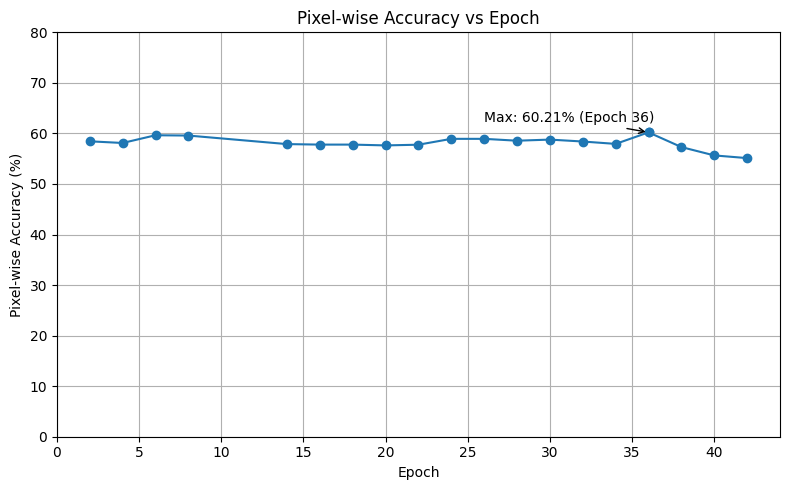

In [ ]:
# Given data
epochs = [36, 6, 8, 24, 26, 30, 28, 2, 32, 4, 34, 14, 16, 18, 22, 20, 38, 40, 42]
accuracy = [60.21, 59.64, 59.58, 58.93, 58.93, 58.78, 58.56, 58.44, 58.40, 58.11,
            57.93, 57.89, 57.79, 57.79, 57.77, 57.63, 57.30, 55.65, 55.12]

# Sort data by epoch
epochs_sorted, accuracy_sorted = zip(*sorted(zip(epochs, accuracy)))

# Plot
plt.figure(figsize=(8,5))
plt.plot(epochs_sorted, accuracy_sorted, marker='o')

# Highlight max point
max_epoch = 36
max_acc = 60.21
plt.scatter(max_epoch, max_acc)

# Annotate max
plt.annotate(f"Max: {max_acc}% (Epoch {max_epoch})",
             xy=(max_epoch, max_acc),
             xytext=(max_epoch-10, max_acc+2),
             arrowprops=dict(arrowstyle="->"))

# Axis settings
plt.xlabel("Epoch")
plt.ylabel("Pixel-wise Accuracy (%)")
plt.title("Pixel-wise Accuracy vs Epoch")
plt.ylim(0, 80) 

plt.grid()
plt.tight_layout()
plt.show()

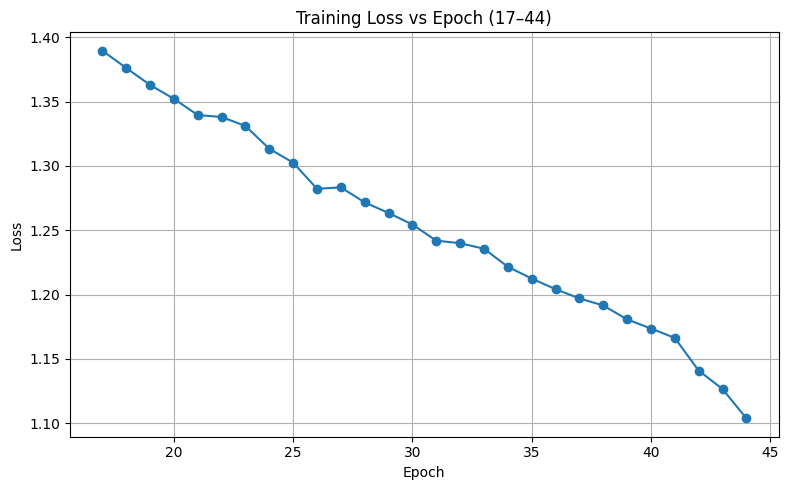

In [ ]:
# Epochs and corresponding losses
epochs = list(range(17, 45))
loss = [
    1.3895, 1.3761, 1.3629, 1.3521,
    1.3395, 1.3380, 1.3310, 1.3133,
    1.3025, 1.2822, 1.2833, 1.2716,
    1.2634, 1.2544, 1.2419, 1.2399,
    1.2356, 1.2216, 1.2124, 1.2042,
    1.1970, 1.1915, 1.1807, 1.1736,
    1.1663, 1.1409, 1.1266, 1.1038
]

# Plot
plt.figure(figsize=(8,5))
plt.plot(epochs, loss, marker='o')

# Labels
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch (17–44)")

plt.grid()
plt.tight_layout()
plt.show()